# Hospitalizaciones y defunciones semnales

## Filtrado de los datos

In [198]:
# Importamos las librerias necesarias
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import PchipInterpolator

Simbología

- CASOS_SINT = casos sintomáticos
- CASOS_HOSP = casos hospitalizaciones 
- CASOS_DEF = casos defunciones 

In [199]:
df = pd.read_csv("influenza_glm_ready.csv") # Importamos el dataset
influenza = df[['SEMANA_RELATIVA', "CASOS_SINT", "CASOS_HOSP", "CASOS_DEF", 
                'FLAG_SINT', 'FLAG_HOSP','FLAG_DEF']] # Filtramos los datos de nuestro interés.
influenza.head().style.set_properties(**{'text-align': 'center'}
                ).hide(axis='index'
                ).set_caption("Resumen de los datos de Influenza")

SEMANA_RELATIVA,CASOS_SINT,CASOS_HOSP,CASOS_DEF,FLAG_SINT,FLAG_HOSP,FLAG_DEF
1,134,40,5,observado,observado,observado
2,145,62,8,observado,observado,observado
3,162,71,9,observado,observado,observado
4,125,58,8,observado,observado,observado
5,102,49,3,observado,observado,observado


In [200]:
influenza["DEF_ACUMULADAS"] = influenza["CASOS_DEF"].cumsum()

## Inspección de los datos

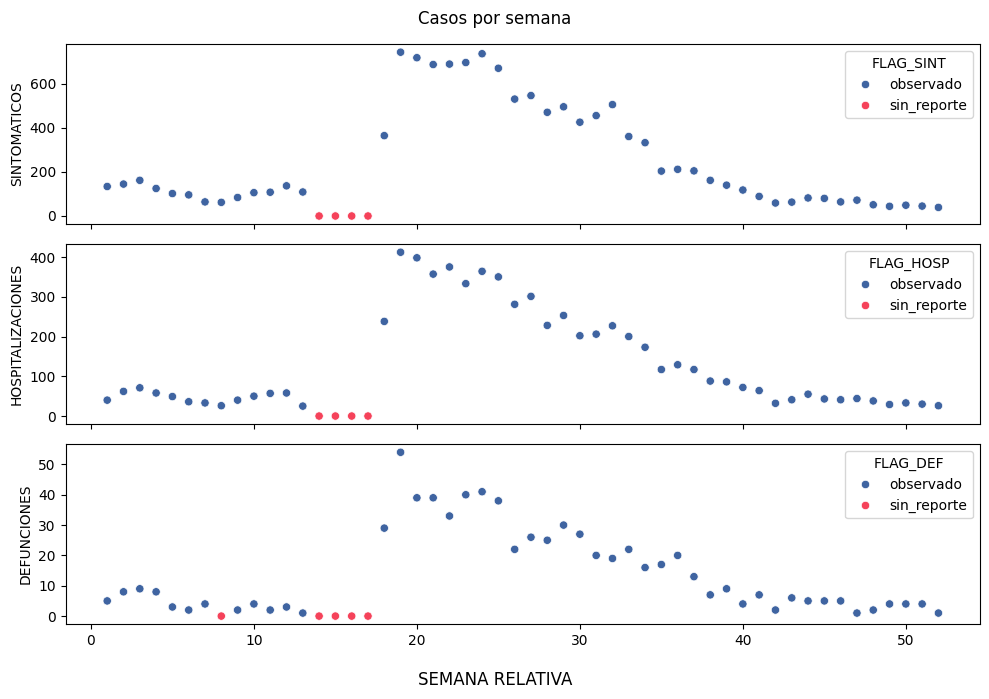

In [201]:
fig, ax = plt.subplots(3, figsize = (10,7))
colors = ['#3f64a1', '#f5425a']

casos =  ["SINT", "HOSP", "DEF"]

for i in range(3):
    sns.scatterplot(
        data=influenza, 
        x = "SEMANA_RELATIVA", 
        y = "CASOS_" + casos[i],
        hue = "FLAG_" + casos[i],
        palette = colors,
        ax = ax[i]
    )
    ax[i].set_xlabel(None)
    
fig.supxlabel("SEMANA RELATIVA")

ax[0].set_ylabel("SINTOMATICOS")
ax[1].set_ylabel("HOSPITALIZACIONES")
ax[2].set_ylabel("DEFUNCIONES")

ax[0].set_xticklabels([])
ax[1].set_xticklabels([])

fig.suptitle("Casos por semana")
#fig.text(1,1,"HOla")
plt.tight_layout()
plt.show()

## a) Preprocesamiento

### Semanas con datos faltantes o no reportados

In [202]:
# Filtramos aquellas semanas para las cuales una de las "FLAGS" aparece como no_reportado
NoReportes = influenza[(influenza["FLAG_SINT"] == "sin_reporte") | 
                       (influenza["FLAG_HOSP"] == "sin_reporte") |
                       (influenza["FLAG_DEF"] == "sin_reporte")
]
def resaltar_sin_reporte(val):
    color = 'cyan' if val == 'sin_reporte' else ''
    return f'background-color: {color}'

estilo_tabla = (
    NoReportes.style
    .hide(axis='index')
    .set_caption("Semanas con al menos uno de los casos etiquetados como sin_reporte")
    .map(resaltar_sin_reporte)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        # Estilo para los encabezados (th)
        dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f2f2f2')]),
        
        # ESTILO PARA EL TÍTULO (caption)
        dict(selector='caption', props=[
            ('font-size', '15px'),    # Aquí ajustas el tamaño (ej. 20px, 1.5em, etc.)
            ('padding', '10px')       # Opcional: espacio entre el título y la tabla
        ])
    ])
)
estilo_tabla

SEMANA_RELATIVA,CASOS_SINT,CASOS_HOSP,CASOS_DEF,FLAG_SINT,FLAG_HOSP,FLAG_DEF,DEF_ACUMULADAS
8,62,26,0,observado,observado,sin_reporte,39
14,0,0,0,sin_reporte,sin_reporte,sin_reporte,51
15,0,0,0,sin_reporte,sin_reporte,sin_reporte,51
16,0,0,0,sin_reporte,sin_reporte,sin_reporte,51
17,0,0,0,sin_reporte,sin_reporte,sin_reporte,51


## b) Modelo 1 - Interpolación

Interpolaremos los datos utilizando un **spline cubico de Hermite**.
Para ello emplearemos la función `PchipInterpolator` de la libreria `SciPy`

**Notas** 
**i)** Para los modelos 1 y 2, la interpolación (y regresión) se realizara en los puntos $x_i=i-\text{iésima semana relativa tal que hay casos observados}$. Por lo tanto el intervalo de los datos será $I=[1, 52]$. Luego cada subintervalo $[i, i+1],\ 1\le i\le 1$ se subdividira en 7 intervalos igualmente espaciados en los cuales se realizaran las predicciones, del modelo correspondiente, dandonos su curva de interpolación o de regresión.

**ii)** En cada caso se agregara al dataset una columna adicional con el valor retornado por cada modelo, para cada uno de los casos (SINT, HOSP, DEF) tanto para los etiquetados como observado, como para los etiquetados como sin_reporte.

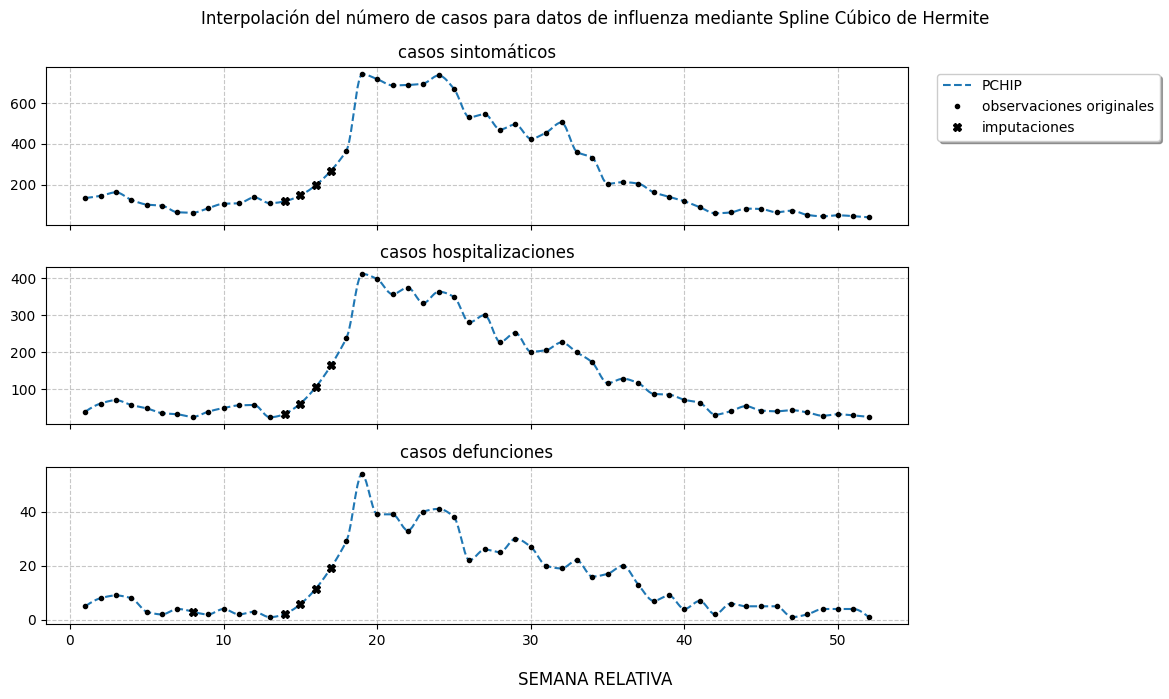

In [203]:
fig, ax = plt.subplots(3, figsize = (12,7))

casos =  ["SINT", "HOSP", "DEF"]
titulos = ["casos sintomáticos", "casos hospitalizaciones", "casos defunciones"]

for i in range(3):
    SemanasConReporte = influenza[influenza["FLAG_" + casos[i]] == "observado"]["SEMANA_RELATIVA"]
    SemanasSinReporte = influenza[influenza["FLAG_" + casos[i]] == "sin_reporte"]["SEMANA_RELATIVA"]
    CasosObservados = influenza[influenza["FLAG_" + casos[i]] == "observado"]["CASOS_" + casos[i]]

    PCHIP = PchipInterpolator(SemanasConReporte, CasosObservados)
    X = np.linspace(1, 52, 7*51+1)
    Y = PCHIP(X)
    Imputaciones = PCHIP(SemanasSinReporte)

    ax[i].plot(X, Y, '--', label = "PCHIP", )
    ax[i].plot(SemanasConReporte, CasosObservados, 'k.', label='observaciones originales')
    ax[i].plot(SemanasSinReporte, Imputaciones, 'kX', label='imputaciones')
    
    ax[i].grid(True, linestyle='--', alpha=0.7)
    ax[i].set_title(titulos[i])
    ax[i].set_xlabel(None)

    influenza["CASOS_" + casos[i] + "_PCHIP"] = Y[0:7*51+1:7]

fig.supxlabel("SEMANA RELATIVA")
fig.suptitle("Interpolación del número de casos para datos de influenza mediante Spline Cúbico de Hermite")

ax[0].set_xticklabels([])
ax[1].set_xticklabels([])
ax[0].legend(loc='upper right', fancybox=True, ncols=1, shadow=True, bbox_to_anchor=(1.3,1))
plt.tight_layout()
plt.show() 

In [204]:
A = np.linspace(1,52,7*51+1)
A[0:7*51+1:7]

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
       40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52.])

### c) Modelo 2 - Regresión Generalizada

Utilizamos un suavizamiento de la serie de tiempo mediante una regresión robusta local ponderada (LOWESS).
Este metodo pondera los datos realizando una predicción en el punto $x_i$ de la serie tomando en consideración solo los primeros $rN-{ésimos}$ vecinos a la derecha de $x_i$, en donde
- $N$ es el tamaño de los datos.
- $0<r\le1$ correspond a la fraccion de los datos sobre los que qureremos ponderar respecto a cada $x_i$.
El valor de  $r$ se escoge segun sea conveniente, por ejemplo, disminuyendo los valores residuales. Para este caso utilizaremos el valor de $r=0.5$ como deafault, lo cual corresponde a ponderar sobre la mitad de los datos.

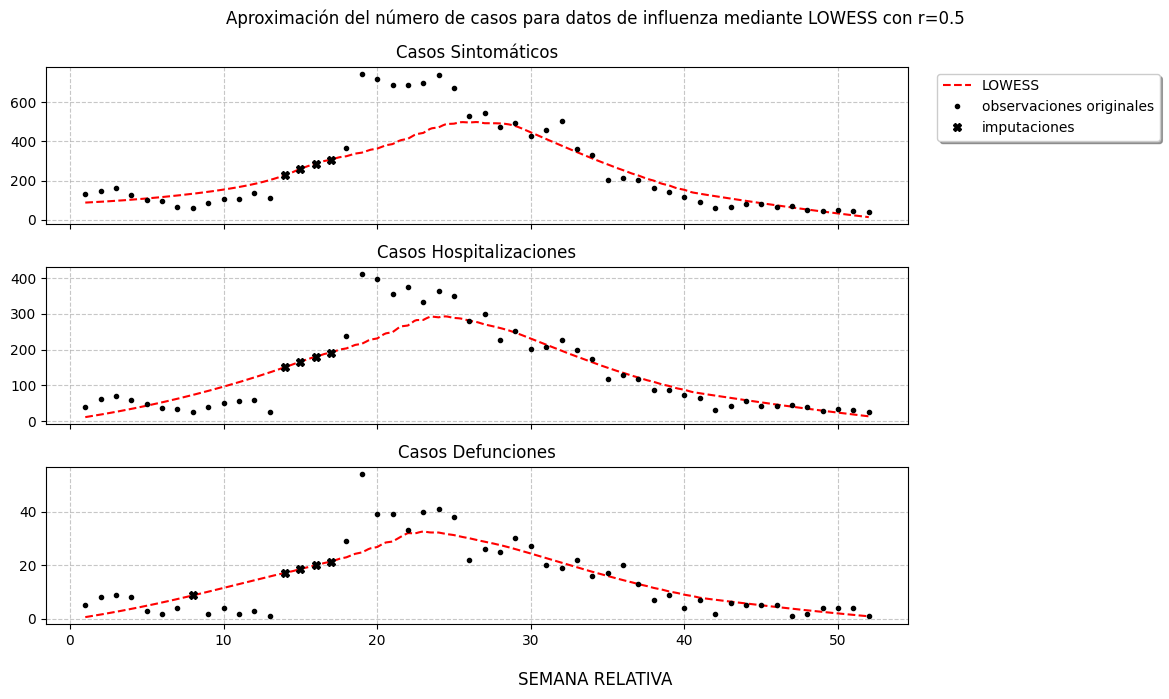

In [205]:
fig, ax = plt.subplots(3, figsize = (12,7))

casos =  ["SINT", "HOSP", "DEF"]
titulos = ["Casos Sintomáticos", "Casos Hospitalizaciones", "Casos Defunciones"]
ErrorModelos = {caso:[0.0] for caso in casos}

for i in range(3):
    SemanasConReporte = influenza[influenza["FLAG_" + casos[i]] == "observado"]["SEMANA_RELATIVA"]
    SemanasSinReporte = influenza[influenza["FLAG_" + casos[i]] == "sin_reporte"]["SEMANA_RELATIVA"]
    CasosObservados = influenza[influenza["FLAG_" + casos[i]] == "observado"]["CASOS_" + casos[i]]
    
    X = np.linspace(1, 52, 7*51+1)

    Regression = lowess(CasosObservados, SemanasConReporte,  xvals=X, frac=0.5)

    ax[i].plot(X, Regression, 'r--', label = "LOWESS", )
    ax[i].plot(SemanasConReporte, CasosObservados, 'k.', label='observaciones originales')
    ax[i].plot(SemanasSinReporte, Regression[7*SemanasSinReporte.index], 'kX', label='imputaciones')

    ax[i].grid(True, linestyle='--', alpha=0.7)
    ax[i].set_title(titulos[i])

    # Cálculo del error cuadrático
    ErroresCuadraticos = (CasosObservados[SemanasConReporte.index] - Regression[7*SemanasConReporte.index]) ** 2
    PromedioErrores = np.mean(ErroresCuadraticos)
    RMSE = np.sqrt(PromedioErrores)
    ErrorModelos[casos[i]].insert(0, RMSE)

    influenza["CASOS_" + casos[i] + "_LOWESS"] = Regression[0:7*51+1:7]


ax[0].set_xticklabels([])
ax[1].set_xticklabels([])

fig.supxlabel("SEMANA RELATIVA")
fig.suptitle("Aproximación del número de casos para datos de influenza mediante LOWESS con r=0.5")
ax[0].legend(loc='upper right', fancybox=True, ncols=1, shadow=True, bbox_to_anchor=(1.3,1))

plt.tight_layout()
plt.show()

### d) Errores de Estimación

Dado que nos interesa saber que tan bien se ajusta la interpolación y la regresión a nuestros datos observados, conviene saber que tan dispersos estan de la curva obtenida. Por lo que utilizaremos la Raiz del Error Cuadrático Medio (**RMSE**)
$$
\sqrt{\frac{1}{n}\sum\left(\hat{y}_i-y_i\right)^2}
$$
La cual nos da la desvación estandar de los valores residuales.  Notemos que en el caso del Modelo 1, que consistio en interpolar los datos, el **RMSE** es 0 en este caso, pues por la naturaleza del modelo, nos interesa que el modelo coincida con los valores observados en los puntos correspondientes cada semana.

En la tabla hemo redondeado los erroes a dos cifras decimales.

In [229]:
df = pd.DataFrame(ErrorModelos)
df.index = ["LOWESS","PCHIP"]
estilo_tabla = (
    df.style
    .set_caption("RMSE para los modelos 1 y 2")
    .map(resaltar_sin_reporte)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        # Estilo para los encabezados (th)
        dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f2f2f2')]),
        
        # ESTILO PARA EL TÍTULO (caption)
        dict(selector='caption', props=[
            ('font-size', '15px'),    # Aquí ajustas el tamaño (ej. 20px, 1.5em, etc.)
            ('padding', '10px')       # Opcional: espacio entre el título y la tabla
        ])
    ])
    .format(precision=2)
)

estilo_tabla


,SINT,HOSP,DEF
LOWESS,121.58,54.62,7.03
PCHIP,0.00,0.00,0.00


Vemos entonces que por diseño del modelo, PCHIP es quien no solo aproxima mejor los datos, sino que los interpola, en este sentido, nuestro modelo esta aprendiendo los datos, lo cual podría no ser la mejor opción si nuestro interes es predecir un aproximado del número de casos para las semanas sin reportes. LOWESS es entonces una opción más adecuada, pues aprende mejor las tendencias de la serie temporal.

### e) Totales y comparación

Calcularemos el total acumulado de hospitalizaciones y defunciones.

En la tabla hemos redondeado el total de casos a cero cifras decimales.

In [227]:
modelos = ["PCHIP", "LOWESS"]
casos =  ["HOSP", "DEF"]
index = ["Hospitalizaciones", "Defunciones"]

CasosAcumulados = {"Datos Originales":[], "PCHIP":[], "LOWESS":[]}

for caso in casos:
    N = influenza["CASOS_" + caso].sum()
    CasosAcumulados["Datos Originales"].append(N)


for modelo in modelos:
    for caso in casos:
        N = influenza["CASOS_" + caso + "_" + modelo].sum()
        CasosAcumulados[modelo].append(N)

CasosAcumulados = pd.DataFrame(CasosAcumulados)
CasosAcumulados.index = casos

estilo_tabla = (
    CasosAcumulados.style
    .set_caption("Casos acumulados para los diferentes modelos")
    .map(resaltar_sin_reporte)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        # Estilo para los encabezados (th)
        dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f2f2f2')]),
        
        # ESTILO PARA EL TÍTULO (caption)
        dict(selector='caption', props=[
            ('font-size', '15px'),    # Aquí ajustas el tamaño (ej. 20px, 1.5em, etc.)
            ('padding', '10px')       # Opcional: espacio entre el título y la tabla
        ])
    ])
    .format(precision=0)
)


estilo_tabla


,Datos Originales,PCHIP,LOWESS
HOSP,6588,6956,6864
DEF,687,729,751
